In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [2]:
os.getcwd()

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\06 Transfer Learning Cats & Dogs'

The Dogs vs. Cats dataset is a common computer vision dataset in which pictures are classified as either including a dog or a cat.

After the dataset is well studied, it can be used to understand and practice how to design, evaluate, and apply convolutional neural networks for image classification.

You will build a classifier with images and try to detect dogs versus cats using CNN.

Train set includes 12500 cat-5026 dog images, validation set includes 1219 cat-1071 dog images and test set incgludes 6897 cat and dogs images together. 

In [3]:
my_data_dir='datam/'    

In [4]:
os.listdir(my_data_dir)

['test', 'train']

In [5]:
train_path = my_data_dir+'train'
test_path = my_data_dir+'test'

In [6]:
os.listdir(train_path)

['cat', 'dog']

* Python assigns the first class **alphabetically** as **0** and the next as **1**. So, in this analysis, the **cat** will be represented as **0** and the **dog** as **1**.

**Let's check how many images there are.**

In [7]:
len(os.listdir(train_path+'/cat'))

12500

In [8]:
len(os.listdir(train_path+'/dog'))

5026

* **Unbalanced** data.

In [9]:
os.listdir(train_path+'/cat')[0]

'cat.0.jpg'

In [10]:
path1=train_path+'/cat'+'/cat.1000.jpg'
path2=train_path+'/dog'+'/dog.1000.jpg'

In [11]:
cat_img=imread(path1)
dog_img=imread(path2)

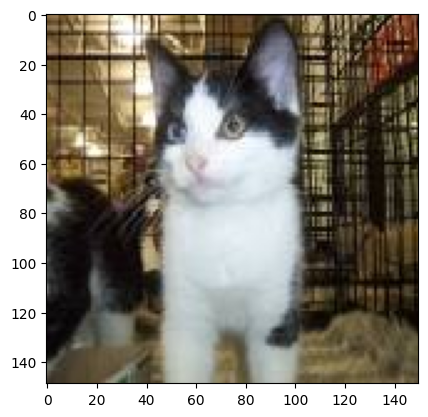

In [12]:
plt.imshow(cat_img);

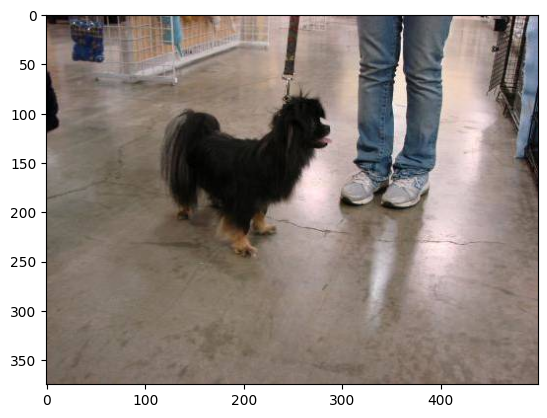

In [13]:
plt.imshow(dog_img);

**Let's decide on the final dimension of these images.**

In [14]:
cat_img.max() # Images haven't resized yet !!! We should do it in next steps...

np.uint8(255)

In [15]:
cat_img.min()

np.uint8(0)

In [16]:
cat_img.shape # coloured images

(149, 150, 3)

In [17]:
dog_img.shape

(375, 499, 3)

In [18]:
x= []
y = []
for image in os.listdir(train_path+'/cat'):
    
    img = imread(train_path+'/cat/'+image)
    d1,d2,colors = img.shape
    x.append(d1)
    y.append(d2)

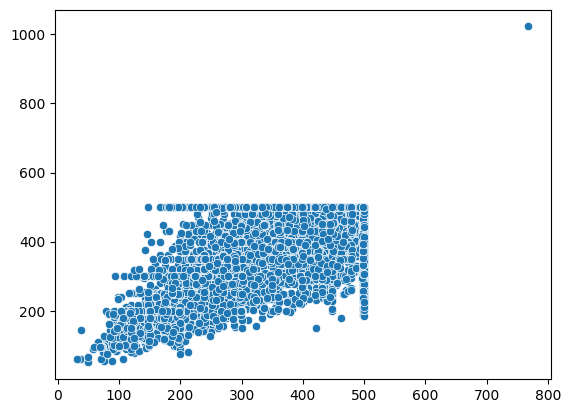

In [19]:
sns.scatterplot(x=x,y=y);

In [20]:
np.mean(x)

np.float64(356.46712)

In [21]:
np.mean(y)

np.float64(410.52264)

In [22]:
image_shape = (256,256,3)

In [23]:
# help(ImageDataGenerator)

**Image Manipulation**

We can use the ImageDataGenerator to manipulate the images with rotation, resizing, and scaling so the model becomes more robust to different images that our data set doesn't have. ImageDataGenerator does the followings.

* Accepts a batch of images used for training.
* Applies a series of random transformations to each image in the batch.
* Replaces the original batch with randomly transformed batch.
* Training the CNN on this randomly transformed batch.

The goal of applying data augmentation is to have a more generalized model.

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               rescale=1/255, # Rescale the image by normalzing it.
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

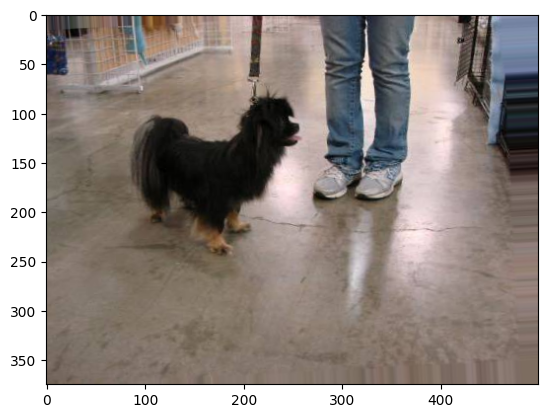

In [26]:
plt.imshow(image_gen.random_transform(dog_img));

* This image has been flipped horizontally.

# Creating the Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D, BatchNormalization

In [28]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) # Max pooling performs better than average pooling since it goes to light colours, and CNN can identify images in light colours. (People can see lighter colored images better).  
model.add(BatchNormalization())           # Max pooling is recommended for images with white backgrounds and min pooling for images with black backgrounds.   

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 127, 127, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 62, 62, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30, 30, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,978,625 (7.55 MB)

 Trainable params: 1,977,601 (7.54 MB)

 Non-trainable params: 1,024 (4.00 KB)

## Early Stopping

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [32]:
batch_size = 64

In [33]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(256,256),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True)

Found 17526 images belonging to 2 classes.


In [34]:
image_gen_test = ImageDataGenerator(rescale=1/255) # This is an empty image generator

test_image_gen = image_gen_test.flow_from_directory(test_path,
                                                    target_size=(256,256),                                                   
                                                    color_mode='rgb',                                                   
                                                    batch_size=batch_size,                                                  
                                                    class_mode='binary', shuffle=False)

Found 2290 images belonging to 2 classes.


## Model Training

In [36]:
results = model.fit(train_image_gen,epochs=3,  # You can choose "epoch = 3" for geting a quick result. 
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 2680s 10s/step - accuracy: 0.7038 - loss: 0.6211 - val_accuracy: 0.5323 - val_loss: 1.3464
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 2622s 10s/step - accuracy: 0.7885 - loss: 0.4634 - val_accuracy: 0.7000 - val_loss: 0.6290
Epoch 3/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 2662s 10s/step - accuracy: 0.8209 - loss: 0.3987 - val_accuracy: 0.7227 - val_loss: 0.5731


# Evaluating the Model

In [37]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.744209,0.536128,0.532314,1.346370
1,0.799156,0.444005,0.700000,0.628982
2,0.823291,0.398158,0.722707,0.573066


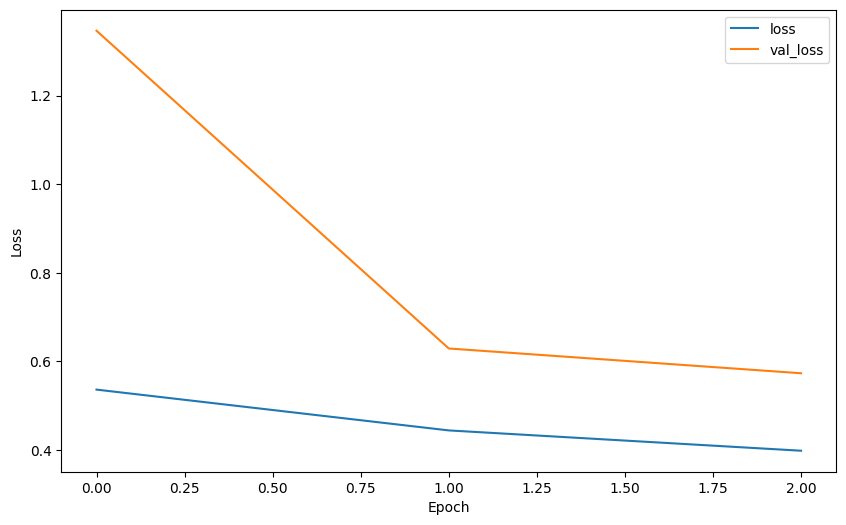

In [38]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

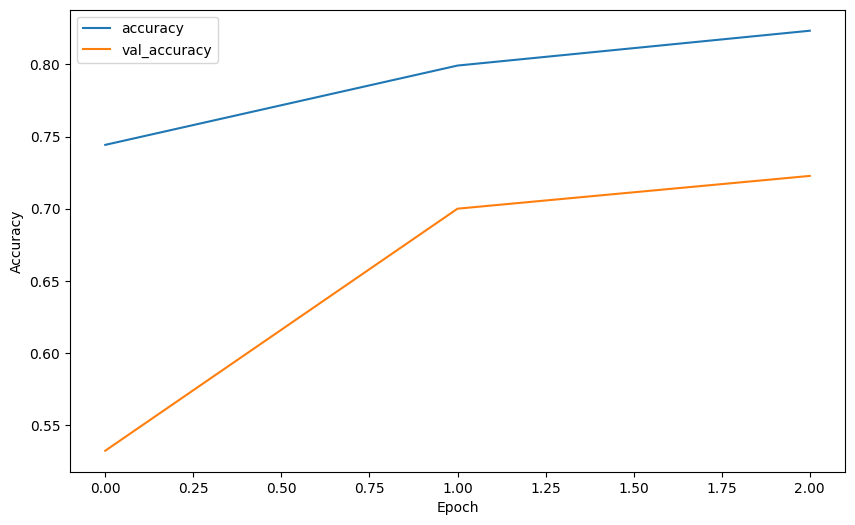

In [39]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

* If we increase epoch number, we will get better (more converged) figures. 

In [40]:
model.metrics_names

['loss', 'compile_metrics']

In [41]:
model.evaluate(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8700 - loss: 0.3203


[0.5730664134025574, 0.7227074503898621]

In [42]:
pred_probabilities = model.predict(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step


In [43]:
pred_probabilities

array([[0.09844799],
       [0.57366884],
       [0.10224634],
       ...,
       [0.845394  ],
       [0.713174  ],
       [0.9695514 ]], dtype=float32)

In [44]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

In [45]:
predictions = pred_probabilities > 0.5

In [46]:
predictions[:50]

array([[False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False]])

In [47]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.67      0.94      0.78      1219
           1       0.87      0.48      0.62      1071

    accuracy                           0.72      2290
   macro avg       0.77      0.71      0.70      2290
weighted avg       0.76      0.72      0.71      2290



0 --> Cat and there are more cat image in our data set. So, model was able to learn better at cat data. 

In [49]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1142,   77],
       [ 558,  513]])

In [50]:
#from tensorflow.keras.models import load_model
#model.save('cat_dog_detector.h5')

In [51]:
from tensorflow.keras.saving import save_model

save_model(model, 'cat_dog.keras')

# Predicting on an Image

In [52]:
train_image_gen.class_indices

{'cat': 0, 'dog': 1}

In [53]:
test_image_gen.class_indices

{'cat': 0, 'dog': 1}

In [54]:
from tensorflow.keras.preprocessing import image

In [55]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the Model
model = tf.keras.models.load_model('cat_dog.keras')

# Open the new image and convert it to a suitable format
image = Image.open("dog.png")
image = image.resize((256, 256))
image_array = np.array(image.convert('RGB')) / 255.0  # scale the image
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the result
predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print('This is a is cat.')
else:
    print('This is a is dog.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
This is a is cat.


* Wrong!

In [56]:
# Load the Model
model = tf.keras.models.load_model('cat_dog.keras')

# Open the new image and convert it to a suitable format
image = Image.open("cat.jpg")
image = image.resize((256, 256))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the result
predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print('This is a is cat.')
else:
    print('This is a is dog.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
This is a is cat.


* Correct!

From **Kaggle**: https://www.kaggle.com/code/bhuvanchennoju/hey-siri-is-it-a-or-class-f1-0-992